# Improve model accuracy using hyperparameter tuning and ensemble methods

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time 
from datetime import datetime 
import warnings 
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, log_loss, make_scorer
)
from xgboost import XGBClassifier
from optuna.samplers import TPESampler
import optuna
plt.style.use('default')
sns.set_palette('husl')

# Load and Prepare Data

In [2]:
# Loading data
df=pd.read_csv(os.path.join('..', 'Processed', 'engineered_data.csv'))
df['date']=pd.to_datetime(df['date'])
df=df.sort_values('date').reset_index(drop=True)
print(f" Data loaded : {df.shape}")

# Prepare features and target
exclude_cols = [
    'outcome', 'date', 'result', 'gf', 'ga', 'xg', 'xga',
    'team', 'opponent', 'day_of_week', 'comp', 'round', 'time'
]
feature_cols=[col for col in df.columns if col not in exclude_cols]

X=df[feature_cols].copy()
y=df['outcome'].copy()

# Time-based train-test split
split_idx=int(len(df)*0.8)
train_dates=df['date'].iloc[:split_idx]
test_dates=df['date'].iloc[split_idx:]

# Use mask-based split
train_mask=df['date']<=train_dates.max()
test_mask=df['date']>train_dates.max()

X_train, X_test=X[train_mask].copy(), X[test_mask].copy()
y_train, y_test=y[train_mask].copy(), y[test_mask].copy()

print(f"Train/Test Split: {X_train.shape}/{X_test.shape}")
print(f"Training: {train_dates.min().date()} to {train_dates.max().date()}")
print(f"Testing: {test_dates.min().date()} to {test_dates.max().date()}")

# Compute Baseline Accuracy
base_acc=y_test.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {base_acc:.4f} ({base_acc*100:.2f}%)")


 Data loaded : (4644, 36)
Train/Test Split: (3726, 28)/(918, 28)
Training: 2019-08-30 to 2024-05-19
Testing: 2024-05-19 to 2025-09-30
Baseline Accuracy: 0.3693 (36.93%)


# Baseline Model - RANDOM FOREST

In [3]:
all_results=[]
print("Training baseline Random Forest")
rf_baseline=RandomForestClassifier(
    n_estimators=200,
    max_depth=15, 
    min_samples_split=20, 
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1, 
    class_weight='balanced'
)
start_time=time.time()
rf_baseline.fit(X_train, y_train)
rf_baseline_time=time.time()-start_time
y_pred_rf=rf_baseline.predict(X_test)
y_pred_proba=rf_baseline.predict_proba(X_test)

rf_baseline_acc=accuracy_score(y_test, y_pred_rf)
rf_baseline_f1=f1_score(y_test, y_pred_rf, average='macro')
rf_baseline_logloss=log_loss(y_test, y_pred_proba)
rf_baseline_precision=precision_score(y_test, y_pred_rf, average='weighted')
rf_baseline_recall=recall_score(y_test, y_pred_rf, average='weighted')
rf_baseline_f1_weighted=f1_score(y_test, y_pred_rf, average='weighted')
print(f"Baseline RF trained in {rf_baseline_time:.2f}s")
print(f"Accuracy: {rf_baseline_acc:.4f} ({rf_baseline_acc*100:.2f}%)")
print(f"F1 Score (Macro): {rf_baseline_f1:.4f}")
print(f"Log Loss: {rf_baseline_logloss:.4f}")
all_results.append({
    'Model': 'Baseline RF',
    'Method': 'Fixed Hyperparameters',
    'Accuracy': rf_baseline_acc,
    'F1 Score (Macro)': rf_baseline_f1,
    'Log Loss': rf_baseline_logloss,
    'Precision (Weighted)': rf_baseline_precision,
    'Recall (Weighted)': rf_baseline_recall,
    'F1 Score (Weighted)': rf_baseline_f1_weighted,
    'Training Time (s)': rf_baseline_time,
    'n_estimators': 200,
    'max_depth': 15
})

Training baseline Random Forest
Baseline RF trained in 0.62s
Accuracy: 0.4662 (46.62%)
F1 Score (Macro): 0.4227
Log Loss: 1.0204


# Basline Model - XGBOOST

In [4]:
print("Training Baseline XGBoost")
y_train_xgb=y_train.map({-1:0, 0:1, 1:2})
y_test_xgb=y_test.map({-1:0, 0:1, 1:2})
xgb_baseline=XGBClassifier(
    n_estimators=200, 
    max_depth=6, 
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1, 
    objective='multi:softprob',
    eval_metric='mlogloss',
)
start_time=time.time()
xgb_baseline.fit(X_train, y_train_xgb)
xgb_baseline_time=time.time()-start_time
y_pred_xgb=xgb_baseline.predict(X_test)
y_pred_proba_xgb=xgb_baseline.predict_proba(X_test)

# Map back=
y_pred_xgb_original=pd.Series(y_pred_xgb).map({0:-1, 1:0, 2:1})
xgb_baseline_acc=accuracy_score(y_test, y_pred_xgb_original)
xgb_baseline_f1=f1_score(y_test, y_pred_xgb_original, average='macro')
xgb_baseline_logloss=log_loss(y_test, y_pred_proba_xgb)
xgb_baseline_precision=precision_score(y_test, y_pred_xgb_original, average='weighted')
xgb_baseline_recall=recall_score(y_test, y_pred_xgb_original, average='weighted')
xgb_baseline_f1_weighted=f1_score(y_test, y_pred_xgb_original, average='weighted')
print(f"Baseline XGB trained in {xgb_baseline_time:.2f}s")
print(f"Accuracy: {xgb_baseline_acc:.4f} ({xgb_baseline_acc*100:.2f}%)")
print(f"F1 Score (Macro): {xgb_baseline_f1:.4f}")
print(f"Log Loss: {xgb_baseline_logloss:.4f}")
all_results.append({
    'Model': 'Baseline XGB',
    'Method': 'Fixed Hyperparameters',
    'Accuracy': xgb_baseline_acc,
    'F1 Score (Macro)': xgb_baseline_f1,
    'Log Loss': xgb_baseline_logloss,
    'Precision (Weighted)': xgb_baseline_precision,
    'Recall (Weighted)': xgb_baseline_recall,
    'F1 Score (Weighted)': xgb_baseline_f1_weighted,
    'Training Time (s)': xgb_baseline_time,
    'n_estimators': 200,
    'max_depth': 6,
    'learning_rate': 0.1
})

Training Baseline XGBoost
Baseline XGB trained in 0.79s
Accuracy: 0.4858 (48.58%)
F1 Score (Macro): 0.4403
Log Loss: 1.0721


# Random Forest - GRIDSEARCHCV TUNING

In [5]:
# Parameter grid for Random Forest
rf_param_grid={
    'n_estimators': [100, 200, 300], 
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'max_features':['sqrt', 'log2']
    
}
print(f"Grid Size: {np.prod([len(v) for v in rf_param_grid.values()])} combinations")

# Time Series Split
tscv=TimeSeriesSplit(n_splits=5)

# Custom scorer for macro F1
f1_scorer=make_scorer(f1_score, average='macro')

print("\Training Random Forest with GridSearchCV")
rf_grid_search=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1
)
start_time=time.time()
rf_grid_search.fit(X_train, y_train)
rf_gs_time=time.time()-start_time
print(f"Grid Search Completed in {rf_gs_time/60:.2f} minutes")
print(f"Best parameters: \n")
for param, value in rf_grid_search.best_params_.items():
    print(f"  {param}: {value}\n")
print(f"Cross validation best score: {rf_grid_search.best_score_:.4f}")
# Evaluate on test set 
y_pred_rf_gs=rf_grid_search.predict(X_test)
y_pred_proba_rf_gs=rf_grid_search.predict_proba(X_test)
rf_gs_acc=accuracy_score(y_test, y_pred_rf_gs)
rf_gs_f1=f1_score(y_test, y_pred_rf_gs, average='macro')
rf_gs_logloss=log_loss(y_test, y_pred_proba_rf_gs)
rf_gs_precision=precision_score(y_test, y_pred_rf_gs, average='weighted')
rf_gs_recall=recall_score(y_test, y_pred_rf_gs, average='weighted')
rf_gs_f1_weighted=f1_score(y_test, y_pred_rf_gs, average='weighted')
print(f"Test Set Performance of Best RF from Grid Search:")
print(f"Accuracy: {rf_gs_acc:.4f} ({rf_gs_acc*100:.2f}%)")
print(f"F1 Score (Macro): {rf_gs_f1:.4f}")
print(f"Log Loss: {rf_gs_logloss:.4f}")
all_results.append({
    'Model': 'Random Forest',
    'Method': 'Grid Search CV',
    'Accuracy': rf_gs_acc,
    'F1 Score (Macro)': rf_gs_f1,
    'Log Loss': rf_gs_logloss,
    'Precision (Weighted)': rf_gs_precision,
    'Recall (Weighted)': rf_gs_recall,
    'F1 Score (Weighted)': rf_gs_f1_weighted,
    'Training Time (s)': rf_gs_time,
    'n_estimators': rf_grid_search.best_params_['n_estimators'],
    'max_depth': rf_grid_search.best_params_['max_depth'],
})

Grid Size: 648 combinations
\Training Random Forest with GridSearchCV
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Grid Search Completed in 5.48 minutes
Best parameters: 

  class_weight: balanced_subsample

  max_depth: 15

  max_features: sqrt

  min_samples_leaf: 5

  min_samples_split: 20

  n_estimators: 100

Cross validation best score: 0.4304
Test Set Performance of Best RF from Grid Search:
Accuracy: 0.4695 (46.95%)
F1 Score (Macro): 0.4368
Log Loss: 1.0246


# XGBOOST - GRIDSEARCHCV TUNING

In [6]:
# Parameter grid for XGBoost
xgb_param_grid={
    'n_estimators': [100, 200, 300],
    'max_depth' : [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample' : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}
print(f"Grid Size: {np.prod([len(v) for v in xgb_param_grid.values()])} combinations")
print("Training XGBoost with GridSearchCV")
xgb_grid=GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        n_jobs=-1,
        objective='multi:softprob',
        eval_metric='mlogloss'
    ),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring=f1_scorer,
    n_jobs=-1,
    verbose=1
)
start_time=time.time()
xgb_grid.fit(X_train, y_train_xgb)
xgb_gs_time=time.time()-start_time
print(f"\nGrid Search Completed in {xgb_gs_time/60:.2f} minutes")
print(f"\nBest parameters: ")
for param, value in xgb_grid.best_params_.items():
    print(f"  {param}: {value}\n")
print(f"Cross Validation Best Score: {xgb_grid.best_score_:.4f}")
# Evaluate on test set
y_pred_xgb_gs=xgb_grid.predict(X_test)
y_pred_proba_xgb_gs=xgb_grid.predict_proba(X_test)
y_pred_xgb_gs_original=pd.Series(y_pred_xgb_gs).map({0:-1, 1:0, 2:1})
xgb_gs_acc=accuracy_score(y_test, y_pred_xgb_gs_original)
xgb_gs_f1=f1_score(y_test, y_pred_xgb_gs_original, average='macro')
xgb_gs_logloss=log_loss(y_test, y_pred_proba_xgb_gs)
xgb_gs_precision=precision_score(y_test, y_pred_xgb_gs_original, average='weighted')
xgb_gs_recall=recall_score(y_test, y_pred_xgb_gs_original, average='weighted')
xgb_gs_f1_weighted=f1_score(y_test, y_pred_xgb_gs_original, average='weighted')
print(f"Test Set Performance of Best XGB from Grid Search:")
print(f"Accuracy: {xgb_gs_acc:.4f} ({xgb_gs_acc*100:.2f}%)")
print(f"F1 Score (Macro): {xgb_gs_f1:.4f}")
print(f"Log Loss: {xgb_gs_logloss:.4f}")
all_results.append({
    'Model': 'XGBoost',
    'Method': 'Grid Search CV + 5-fold CV',
    'Accuracy': xgb_gs_acc,
    'F1 Score (Macro)': xgb_gs_f1,
    'Log Loss': xgb_gs_logloss,
    'Precision (Weighted)': xgb_gs_precision,
    'Recall (Weighted)': xgb_gs_recall,
    'F1 Score (Weighted)': xgb_gs_f1_weighted,
    'Training Time (s)': xgb_gs_time,
    'n_estimators': xgb_grid.best_params_['n_estimators'],
    'max_depth': xgb_grid.best_params_['max_depth'],
    'learning_rate': xgb_grid.best_params_['learning_rate']
})


Grid Size: 243 combinations
Training XGBoost with GridSearchCV
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Grid Search Completed in 2.48 minutes

Best parameters: 
  colsample_bytree: 0.7

  learning_rate: 0.1

  max_depth: 4

  n_estimators: 100

  subsample: 0.8

Cross Validation Best Score: 0.4314
Test Set Performance of Best XGB from Grid Search:
Accuracy: 0.4989 (49.89%)
F1 Score (Macro): 0.4270
Log Loss: 1.0033


# RF - OPTUNA BAYESIAN OPTIMIZATION

In [7]:
# Random forest with Optuna 
print("Optimizing Random Forest with Optuna")
def rf_objective(trial):
    params={
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'max_depth' : trial.suggest_int('max_depth', 5, 30), 
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])
    }
    # Time Series CV 
    scores=[]
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val=X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val=y_train.iloc[train_idx], y_train.iloc[val_idx]
        model=RandomForestClassifier(**params)
        model.fit(X_tr, y_tr)
        y_pred=model.predict(X_val)
        score=f1_score(y_val, y_pred, average='macro')
        scores.append(score)
    return np.mean(scores)

# Create Study 
optuna.logging.set_verbosity(optuna.logging.WARNING)
rf_study=optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
print("Running 50 trials...")
start_time=time.time()
rf_study.optimize(rf_objective, n_trials=50)
rf_optuna_time=time.time()-start_time

print(f"Optuna completed in {rf_optuna_time/60:.2f}minutes")
print("Best Parameters: ")
for param, value in rf_study.best_params.items():
    print(f"  {param}: {value}")

print(f"Best CV F1-Score (Macro): {rf_study.best_value:.4f}")

# Train final model with best params
rf_optuna=RandomForestClassifier(
    **rf_study.best_params, random_state=42, n_jobs=-1
)
rf_optuna.fit(X_train, y_train)
y_pred_optuna=rf_optuna.predict(X_test)
y_pred_proba_optuna=rf_optuna.predict_proba(X_test)
rf_optuna_acc=accuracy_score(y_test, y_pred_optuna)
rf_optuna_f1=f1_score(y_test, y_pred_optuna, average='macro')
rf_optuna_logloss=log_loss(y_test, y_pred_proba_optuna)
rf_optuna_precision=precision_score(y_test, y_pred_optuna, average='weighted')
rf_optuna_recall=recall_score(y_test, y_pred_optuna, average='weighted')
rf_optuna_f1_weighted=f1_score(y_test, y_pred_optuna, average='weighted')
print(f"Test Set Performance of Best RF from Optuna:")
print(f"Accuracy: {rf_optuna_acc:.4f} ({rf_optuna_acc*100:.2f}%)")  
print(f"F1 Score (Macro): {rf_optuna_f1:.4f}")
print(f"Log Loss: {rf_optuna_logloss:.4f}")
all_results.append({
    'Model': 'Random Forest',
    'Method': 'Optuna Hyperparameter Tuning',
    'Accuracy': rf_optuna_acc,
    'F1 Score (Macro)': rf_optuna_f1,
    'Log Loss': rf_optuna_logloss,
    'Precision (Weighted)': rf_optuna_precision,
    'Recall (Weighted)': rf_optuna_recall,
    'F1 Score (Weighted)': rf_optuna_f1_weighted,
    'Training Time (s)': rf_optuna_time,
    'n_estimators': rf_study.best_params['n_estimators'],
    'max_depth': rf_study.best_params['max_depth'],
})

Optimizing Random Forest with Optuna
Running 50 trials...
Optuna completed in 5.48minutes
Best Parameters: 
  n_estimators: 472
  max_depth: 15
  min_samples_split: 17
  min_samples_leaf: 15
  max_features: None
  class_weight: balanced_subsample
Best CV F1-Score (Macro): 0.4363
Test Set Performance of Best RF from Optuna:
Accuracy: 0.4706 (47.06%)
F1 Score (Macro): 0.4324
Log Loss: 1.0135


# XGBOOST OPTUNA BAYESIAN OPTIMIZATION

In [8]:
def xgb_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'random_state': 42,
            'n_jobs': -1,
            'objective': 'multi:softprob',
            'eval_metric': 'mlogloss'
        }
        
        # Time series CV
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train_xgb.iloc[train_idx], y_train_xgb.iloc[val_idx]
            
            model = XGBClassifier(**params)
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            
            # Map back
            y_pred_mapped = pd.Series(y_pred).map({0: -1, 1: 0, 2: 1}).values
            y_val_mapped = y_train.iloc[val_idx].values
            
            score = f1_score(y_val_mapped, y_pred_mapped, average='macro')
            scores.append(score)
        
        return np.mean(scores)
    
xgb_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))

print("  Running 50 trials...")
start_time = time.time()
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=False)
xgb_optuna_time = time.time() - start_time

print(f"\nOptuna completed in {xgb_optuna_time/60:.2f} minutes")
print(f"\nBest parameters:")
for param, value in xgb_study.best_params.items():
    print(f"  {param}: {value}")

print(f"\nBest CV F1-Macro: {xgb_study.best_value:.4f}")

# Train final model
xgb_optuna = XGBClassifier(**xgb_study.best_params, random_state=42, n_jobs=-1,
                        objective='multi:softprob', eval_metric='mlogloss')
xgb_optuna.fit(X_train, y_train_xgb)

y_pred_xgb_optuna = xgb_optuna.predict(X_test)
y_pred_proba_xgb_optuna = xgb_optuna.predict_proba(X_test)

# Map back
y_pred_xgb_optuna_original = pd.Series(y_pred_xgb_optuna).map({0: -1, 1: 0, 2: 1}).values

xgb_optuna_acc = accuracy_score(y_test, y_pred_xgb_optuna_original)
xgb_optuna_f1 = f1_score(y_test, y_pred_xgb_optuna_original, average='macro')
xgb_optuna_logloss = log_loss(y_test, y_pred_proba_xgb_optuna)
xgb_optuna_precision = precision_score(y_test, y_pred_xgb_optuna_original, average='weighted')
xgb_optuna_recall = recall_score(y_test, y_pred_xgb_optuna_original, average='weighted')
xgb_optuna_f1_weighted = f1_score(y_test, y_pred_xgb_optuna_original, average='weighted')

print(f"\nTest set performance:")
print(f"  Accuracy: {xgb_optuna_acc:.4f} ({xgb_optuna_acc*100:.2f}%)")
print(f"  F1 Score (Macro): {xgb_optuna_f1:.4f}")
print(f"  Log Loss: {xgb_optuna_logloss:.4f}")
print(f"  Improvement: {(xgb_optuna_acc - xgb_baseline_acc)*100:+.2f}pp")

all_results.append({
    'Model': 'XGBoost (Optuna)',
    'Method': 'Bayesian Optimization',
    'Accuracy': xgb_optuna_acc,
    'F1 Score (Macro)': xgb_optuna_f1,
    'Log Loss': xgb_optuna_logloss,
    'Precision (Weighted)': xgb_optuna_precision,
    'Recall (Weighted)': xgb_optuna_recall,
    'F1 Score (Weighted)': xgb_optuna_f1_weighted,
    'Training Time (s)': xgb_optuna_time,
    'n_estimators': xgb_study.best_params['n_estimators'],
    'max_depth': xgb_study.best_params['max_depth'],
    'learning_rate': xgb_study.best_params['learning_rate']
})

  Running 50 trials...

Optuna completed in 3.46 minutes

Best parameters:
  n_estimators: 493
  max_depth: 5
  learning_rate: 0.04947455333172755
  subsample: 0.63197823231335
  colsample_bytree: 0.7435557078373036
  min_child_weight: 8

Best CV F1-Macro: 0.4361

Test set performance:
  Accuracy: 0.4978 (49.78%)
  F1 Score (Macro): 0.4505
  Log Loss: 1.0510
  Improvement: +1.20pp


# ENSEMBLE METHODS

In [9]:
# Creating Voting Ensemble
voting_clf=VotingClassifier(
    estimators=[
        ('rf', rf_grid_search.best_estimator_),
        ('xgb', xgb_grid.best_estimator_)
    ],
    voting='soft',
    n_jobs=-1
) 
start_time=time.time()
voting_clf.fit(X_train, y_train_xgb)
voting_time=time.time()-start_time

y_pred_voting=voting_clf.predict(X_test)
y_pred_proba_voting=voting_clf.predict_proba(X_test)
y_pred_voting_original=pd.Series(y_pred_voting).map({0:-1, 1:0, 2:1})
voting_acc=accuracy_score(y_test, y_pred_voting_original)
voting_f1=f1_score(y_test, y_pred_voting_original, average='macro')
voting_logloss=log_loss(y_test, y_pred_proba_voting)
voting_precision=precision_score(y_test, y_pred_voting_original, average='weighted')
voting_recall=recall_score(y_test, y_pred_voting_original, average='weighted')
voting_f1_weighted=f1_score(y_test, y_pred_voting_original, average='weighted')
print(f"Voting Classifier trained in {voting_time:.2f}s")
print(f"Accuracy: {voting_acc:.4f} ({voting_acc*100:.2f}%)")
print(f"F1 Score (Macro): {voting_f1:.4f}")
print(f"Log Loss: {voting_logloss:.4f}")
all_results.append({
    'Model': 'Voting Classifier (RF + XGB)',
    'Method': 'Soft Voting Ensemble',
    'Accuracy': voting_acc,
    'F1 Score (Macro)': voting_f1,
    'Log Loss': voting_logloss,
    'Precision (Weighted)': voting_precision,
    'Recall (Weighted)': voting_recall,
    'F1 Score (Weighted)': voting_f1_weighted,
    'Training Time (s)': voting_time,
    'n_estimators': 'Ensemble',
    'max_depth': 'Ensemble'
})


# Stacking Classifier 
stacking_clf=StackingClassifier(
    estimators=[
        ('rf', rf_grid_search.best_estimator_),
        ('xgb', xgb_grid.best_estimator_)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)
start_time=time.time()
stacking_clf.fit(X_train, y_train_xgb)
stacking_time=time.time()-start_time

y_pred_stacking=stacking_clf.predict(X_test)
y_pred_proba_stacking=stacking_clf.predict_proba(X_test)
y_pred_stacking_original=pd.Series(y_pred_stacking).map({0:-1, 1:0, 2:1})
stacking_acc=accuracy_score(y_test, y_pred_stacking_original)
stacking_f1=f1_score(y_test, y_pred_stacking_original, average='macro')
stacking_logloss=log_loss(y_test, y_pred_proba_stacking)
stacking_precision=precision_score(y_test, y_pred_stacking_original, average='weighted')
stacking_recall=recall_score(y_test, y_pred_stacking_original, average='weighted')
stacking_f1_weighted=f1_score(y_test, y_pred_stacking_original, average='weighted')
print(f"Stacking Classifier trained in {stacking_time:.2f}s")
print(f"Accuracy: {stacking_acc:.4f} ({stacking_acc*100:.2f}%)")
print(f"F1 Score (Macro): {stacking_f1:.4f}")
print(f"Log Loss: {stacking_logloss:.4f}")
all_results.append({
    'Model': 'Stacking Classifier (RF + XGB)',
    'Method': 'Stacking + Logistic Meta-learner',
    'Accuracy': stacking_acc,
    'F1 Score (Macro)': stacking_f1,
    'Log Loss': stacking_logloss,
    'Precision (Weighted)': stacking_precision,
    'Recall (Weighted)': stacking_recall,
    'F1 Score (Weighted)': stacking_f1_weighted,
    'Training Time (s)': stacking_time,
    'n_estimators': 'Ensemble',
    'max_depth': 'Ensemble'
})

Voting Classifier trained in 3.98s
Accuracy: 0.4956 (49.56%)
F1 Score (Macro): 0.4264
Log Loss: 1.0056
Stacking Classifier trained in 7.58s
Accuracy: 0.5131 (51.31%)
F1 Score (Macro): 0.3938
Log Loss: 0.9936


# RESULTS COMPARISON 

In [10]:
# Comprehensive results dataframe 
results_df=pd.DataFrame(all_results)
results_df=results_df.sort_values('F1 Score (Macro)', ascending=False)

print("All Models Performance (Sorted by F1 Score Macro):")
print(results_df[['Model', 'Method', 'Accuracy','F1 Score (Macro)', 'Log Loss', 'Precision (Weighted)', 'Recall (Weighted)', 'F1 Score (Weighted)', 'Training Time (s)']].to_string(index=False))

# Save Results 
results_path=os.path.join('..', 'results')
if not os.path.exists(results_path):
    os.makedirs(results_path)
results_df.to_csv(os.path.join(results_path, 'hyper_tuning_results.csv'), index=False)
print(f"Results saved to {results_path}\n")

# Final Best Model Details
best_idx=results_df['F1 Score (Macro)'].idxmax()
best_row=results_df.loc[best_idx]

print(f" Best Model: {best_row['Model']}")
print(f" Method: {best_row['Method']}")
print(f" Accuracy: {best_row['Accuracy']:.4f} ({best_row['Accuracy']*100:.2f}%)")
print(f" F1 Score (Macro): {best_row['F1 Score (Macro)']:.4f}")
print(f" Log Loss: {best_row['Log Loss']:.4f}")
print(f" Training Time (s): {best_row['Training Time (s)']:.2f}s")
print(f" vs Baseline: {(best_row['Accuracy'] - xgb_baseline_acc)*100:+.2f}pp")

All Models Performance (Sorted by F1 Score Macro):
                         Model                           Method  Accuracy  F1 Score (Macro)  Log Loss  Precision (Weighted)  Recall (Weighted)  F1 Score (Weighted)  Training Time (s)
              XGBoost (Optuna)            Bayesian Optimization  0.497821          0.450531  1.050961              0.472577           0.497821             0.474570         207.702048
                  Baseline XGB            Fixed Hyperparameters  0.485839          0.440263  1.072110              0.459517           0.485839             0.464296           0.789191
                 Random Forest                   Grid Search CV  0.469499          0.436780  1.024594              0.451858           0.469499             0.457556         328.524468
                 Random Forest     Optuna Hyperparameter Tuning  0.470588          0.432353  1.013465              0.448145           0.470588             0.455764         328.552311
                       XGBoost    

# Save the Best Model

In [11]:
# Saving the best model
if best_row['Model'] == 'XGBoost (Optuna)':
    final_model = xgb_optuna
elif best_row['Model'] == 'Random Forest' and best_row['Method'] == 'Optuna Hyperparameter Tuning':
    final_model = rf_optuna
elif best_row['Model'] == 'Random Forest' and best_row['Method'] == 'Grid Search CV':
    final_model = rf_grid_search.best_estimator_
elif best_row['Model'] == 'XGBoost':
    final_model = xgb_grid.best_estimator_
elif best_row['Model'] == 'Baseline XGB':
    final_model = xgb_baseline
elif best_row['Model'] == 'Baseline RF':
    final_model = rf_baseline
elif best_row['Model'] == 'Voting Classifier (RF + XGB)':
    final_model = voting_clf
elif best_row['Model'] == 'Stacking Classifier (RF + XGB)':
    final_model = stacking_clf
else:
    raise ValueError(f"Unknown model: {best_row['Model']}")

# Create Model package
final_model_pkg={
    'model': final_model,
    'model_name': best_row['Model'],
    'method': best_row['Method'],
    'accuracy': best_row['Accuracy'],
    'f1_macro': best_row['F1 Score (Macro)'],
    'log_loss': best_row['Log Loss'],
    'feature_cols': feature_cols,
    'best_params': best_row.to_dict(),
    'time_trained': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'all_results': results_df.to_dict('records')
}
final_model_path=os.path.join(results_path, 'final_model.pkl')
joblib.dump(final_model_pkg, final_model_path)
print(f"Final model saved to {final_model_path}")

Final model saved to ..\results\final_model.pkl


# Visualization of tuned models

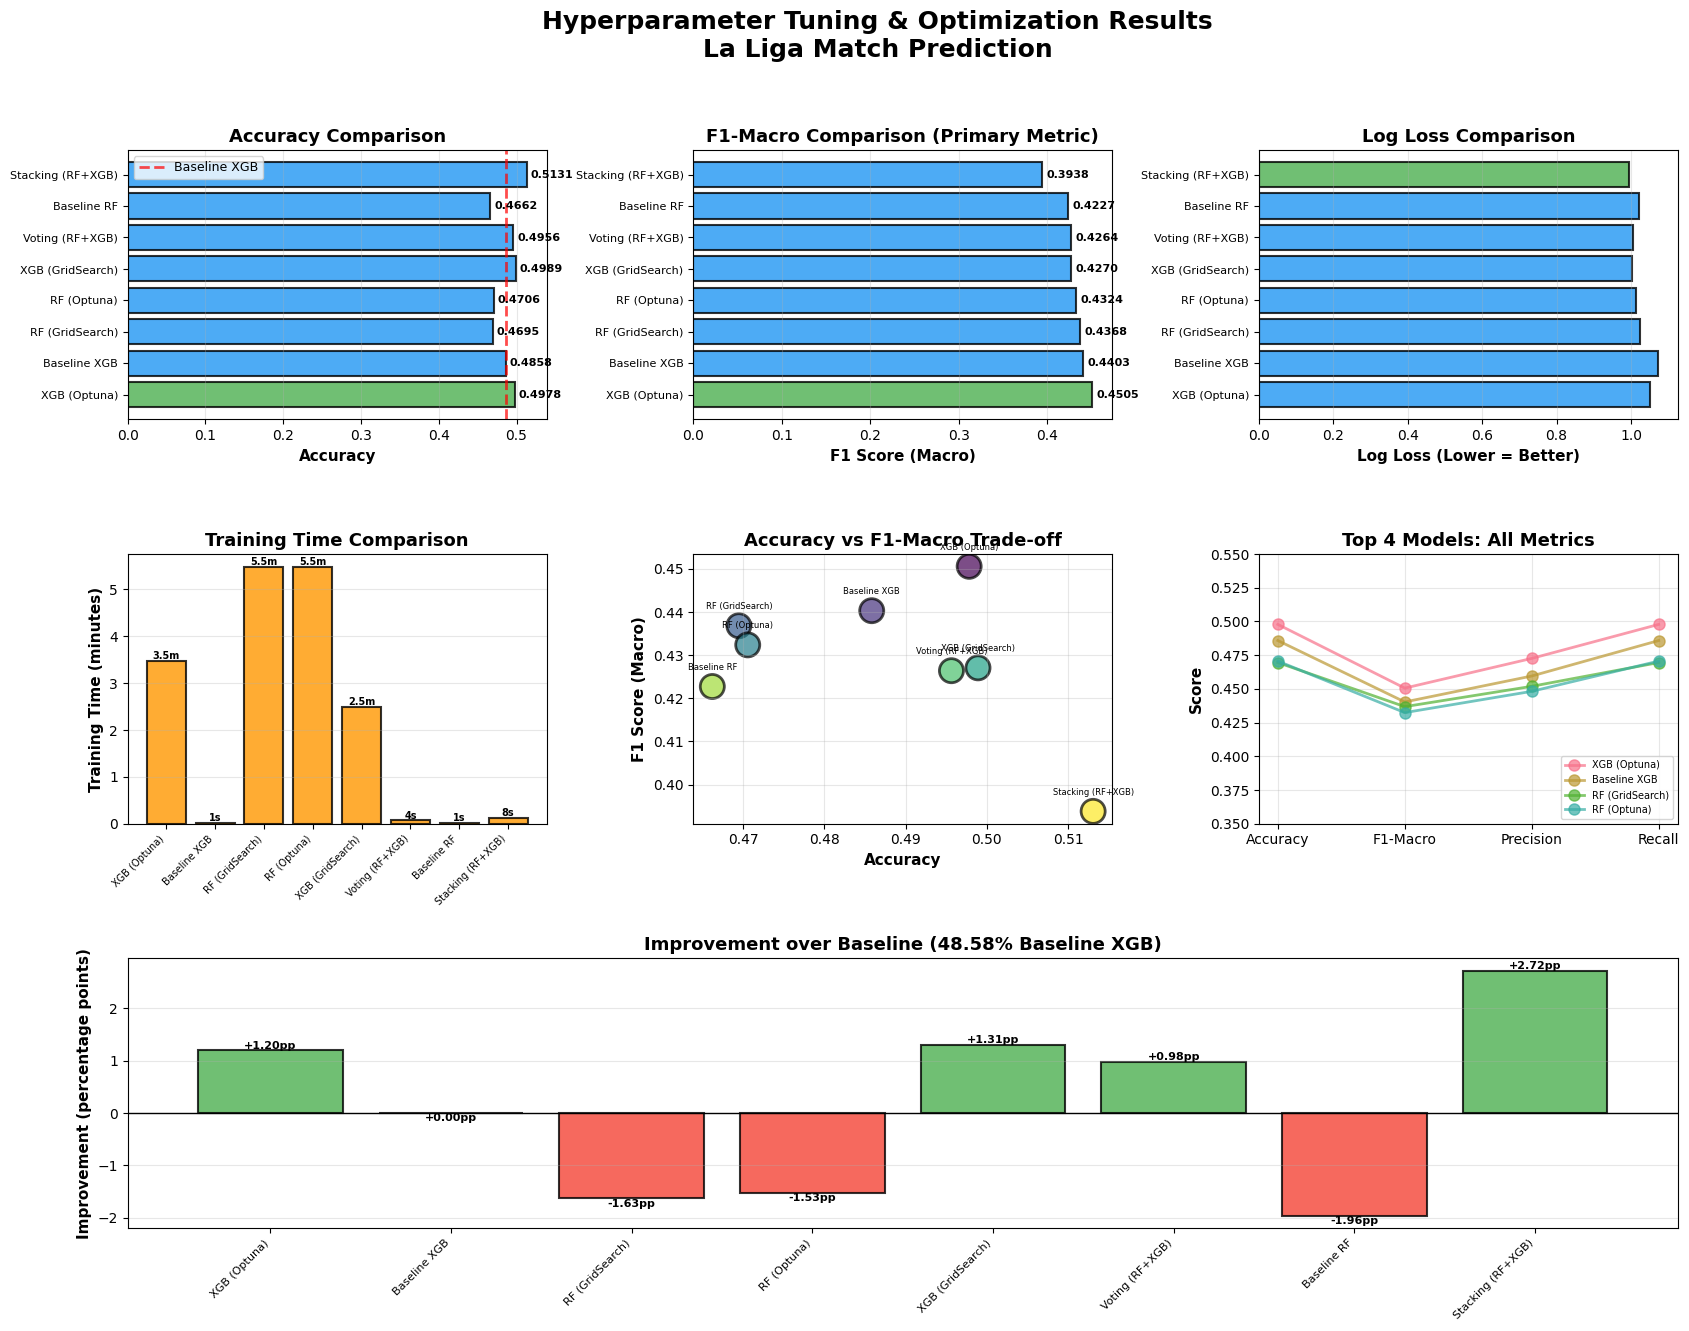

Visualization saved to ..\results



In [12]:
# Creating comprehensive visualizations of the results
fig=plt.figure(figsize=(20, 14)) 
gs=fig.add_gridspec(3, 3, hspace=0.5, wspace=0.35)  

def get_short_name(row):
    model = row['Model']
    method = row['Method']
    if model == 'XGBoost (Optuna)':
        return 'XGB (Optuna)'
    elif model == 'XGBoost':
        return 'XGB (GridSearch)'
    elif model == 'Random Forest' and 'Optuna' in method:
        return 'RF (Optuna)'
    elif model == 'Random Forest' and 'Grid' in method:
        return 'RF (GridSearch)'
    elif model == 'Baseline XGB':
        return 'Baseline XGB'
    elif model == 'Baseline RF':
        return 'Baseline RF'
    elif 'Voting' in model:
        return 'Voting (RF+XGB)'
    elif 'Stacking' in model:
        return 'Stacking (RF+XGB)'
    return model

models_short = [get_short_name(row) for _, row in results_df.iterrows()]

# Accuracy Comparison
ax1=fig.add_subplot(gs[0, 0])
colors=['#4CAF50' if i == best_idx else '#2196F3' for i in results_df.index]
bars=ax1.barh(range(len(models_short)), results_df['Accuracy'].values, color=colors, alpha=0.8,
              edgecolor='black', linewidth=1.5)
ax1.set_yticks(range(len(models_short)))
ax1.set_yticklabels(models_short, fontsize=8)
ax1.axvline(xgb_baseline_acc, color='red', linestyle='--', linewidth=2, label='Baseline XGB', alpha=0.7)
ax1.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# Add values on bars
for i, (bar, acc) in enumerate(zip(bars, results_df['Accuracy'])):
    width = bar.get_width()
    ax1.text(width + 0.005, i, f'{acc:.4f}',
            ha='left', va='center', fontsize=8, fontweight='bold')

# F1 Score Comparison
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.barh(range(len(models_short)), results_df['F1 Score (Macro)'].values, color=colors, alpha=0.8,
               edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(models_short)))
ax2.set_yticklabels(models_short, fontsize=8)
ax2.set_xlabel('F1 Score (Macro)', fontsize=11, fontweight='bold')
ax2.set_title('F1-Macro Comparison (Primary Metric)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, (bar, f1) in enumerate(zip(bars, results_df['F1 Score (Macro)'])):
    width = bar.get_width()
    ax2.text(width + 0.005, i, f'{f1:.4f}',
            ha='left', va='center', fontsize=8, fontweight='bold')

# Log Loss Comparison 
ax3 = fig.add_subplot(gs[0, 2])
colors_inv = ['#4CAF50' if i == results_df['Log Loss'].idxmin() else '#2196F3' 
              for i in results_df.index]
bars = ax3.barh(range(len(models_short)), results_df['Log Loss'].values, color=colors_inv, alpha=0.8,
               edgecolor='black', linewidth=1.5)
ax3.set_yticks(range(len(models_short)))
ax3.set_yticklabels(models_short, fontsize=8)
ax3.set_xlabel('Log Loss (Lower = Better)', fontsize=11, fontweight='bold')
ax3.set_title('Log Loss Comparison', fontsize=13, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Training Time Comparison
ax4 = fig.add_subplot(gs[1, 0])
times_min = results_df['Training Time (s)'].values / 60
bars = ax4.bar(range(len(models_short)), times_min, color='#FF9800', alpha=0.8,
              edgecolor='black', linewidth=1.5)
ax4.set_xticks(range(len(models_short)))
ax4.set_xticklabels(models_short, rotation=45, ha='right', fontsize=7)
ax4.set_ylabel('Training Time (minutes)', fontsize=11, fontweight='bold')
ax4.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

for bar, time_min in zip(bars, times_min):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{time_min:.1f}m' if time_min > 1 else f'{time_min*60:.0f}s',
            ha='center', va='bottom', fontsize=7, fontweight='bold')

# Accuracy vs F1-Macro Scatter
ax5 = fig.add_subplot(gs[1, 1])
scatter = ax5.scatter(results_df['Accuracy'], results_df['F1 Score (Macro)'],
                     s=300, c=range(len(results_df)), cmap='viridis',
                     alpha=0.7, edgecolors='black', linewidth=2)

for i, (acc, f1, model) in enumerate(zip(results_df['Accuracy'], 
                                          results_df['F1 Score (Macro)'],
                                          models_short)):
    ax5.annotate(model.replace('\n', ' '), (acc, f1), fontsize=6, ha='center',
                xytext=(0, 12), textcoords='offset points')

ax5.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax5.set_ylabel('F1 Score (Macro)', fontsize=11, fontweight='bold')
ax5.set_title('Accuracy vs F1-Macro Trade-off', fontsize=13, fontweight='bold')
ax5.grid(alpha=0.3)

# All Metrics Comparison 
ax6 = fig.add_subplot(gs[1, 2])
x_pos = np.arange(4)

for idx in range(min(4, len(results_df))):  # Top 4 models
    row = results_df.iloc[idx]
    values = [row['Accuracy'], row['F1 Score (Macro)'], row['Precision (Weighted)'], row['Recall (Weighted)']]
    ax6.plot(x_pos, values, marker='o', linewidth=2, markersize=8,
            label=models_short[idx].replace('\n', ' '), alpha=0.7)

ax6.set_xticks(x_pos)
ax6.set_xticklabels(['Accuracy', 'F1-Macro', 'Precision', 'Recall'], fontsize=10)
ax6.set_ylabel('Score', fontsize=11, fontweight='bold')
ax6.set_title('Top 4 Models: All Metrics', fontsize=13, fontweight='bold')
ax6.legend(fontsize=7, loc='lower right')
ax6.grid(alpha=0.3)
ax6.set_ylim([0.35, 0.55])

# Improvement over Baseline
ax7 = fig.add_subplot(gs[2, :])
improvements = (results_df['Accuracy'].values - xgb_baseline_acc) * 100
colors_imp = ['#4CAF50' if imp > 0 else '#f44336' for imp in improvements]

bars = ax7.bar(range(len(models_short)), improvements, color=colors_imp, alpha=0.8,
              edgecolor='black', linewidth=1.5)
ax7.axhline(0, color='black', linestyle='-', linewidth=1)
ax7.set_ylabel('Improvement (percentage points)', fontsize=11, fontweight='bold')
ax7.set_title(f'Improvement over Baseline ({xgb_baseline_acc*100:.2f}% Baseline XGB)', fontsize=13, fontweight='bold')
ax7.set_xticks(range(len(models_short)))
ax7.set_xticklabels(models_short, rotation=45, ha='right', fontsize=8)
ax7.grid(axis='y', alpha=0.3)

for bar, imp in zip(bars, improvements):
    height = bar.get_height()
    va = 'bottom' if height > 0 else 'top'
    ax7.text(bar.get_x() + bar.get_width()/2., height,
            f'{imp:+.2f}pp',
            ha='center', va=va, fontsize=8, fontweight='bold')

plt.suptitle('Hyperparameter Tuning & Optimization Results\nLa Liga Match Prediction',
            fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(results_path, 'tuning_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Visualization saved to {results_path}\n")